# TP Extra — Evaluación de modelos y mejoras sobre el KNN de Riesgo Crediticio

## Contexto

En el TP anterior (`TP_Clasificacion_KNN_Riesgo_Crediticio.ipynb`) entrenamos un KNN que llegó a un **Accuracy de 92.5%** sobre `X_test`. A primera vista es un número muy bueno. Pero al mirar la matriz de confusión con más atención aparece un problema:

> El conjunto de test tiene **6 clientes de riesgo "Alto"**, y el modelo solo detectó **4 de esos 6** (falló en 2). Eso es un **Recall de la clase "Alto" = 0.67**, mucho menos alegre que el 92.5% de Accuracy.

Este cuaderno **no reemplaza** al anterior: lo complementa. Vamos a:

1. Entender **por qué** el Accuracy puede ser una métrica engañosa en este problema (y en general, con clases desbalanceadas).
2. Repasar con más profundidad la teoría de evaluación de modelos (matriz de confusión, Precision/Recall/F1, ROC-AUC vs. Precision-Recall AUC).
3. Probar, **uno por uno**, los cambios que se sugirieron para mejorar la detección de clientes de Alto riesgo:
   - Elegir `k` optimizando Recall en vez de Accuracy.
   - Probar `weights='distance'`.
   - Ajustar el umbral de decisión (no quedarnos con el 0.5 por defecto).
   - Atacar el desbalance de clases con sobremuestreo (oversampling).
   - Revisar la distancia Manhattan, pero mirando Recall y no solo Accuracy.
4. Agregar dos temas que quedaron afuera del TP original y que son importantes para interpretar todo lo anterior: el **costo de negocio** de cada tipo de error, y la **maldición de la dimensionalidad** en KNN.

Todo el análisis usa el **mismo dataset, el mismo split (`random_state=42`) y las mismas variables** que el TP original, para que los resultados sean comparables.


## 1. Preparativos

Mismas importaciones, mismos datos, misma división train/test que en el TP original. Agregamos algunas herramientas nuevas que vamos a necesitar: `DummyClassifier`, `make_scorer`, `precision_recall_curve`, `average_precision_score` y `resample`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    make_scorer, recall_score, precision_score, f1_score,
)

df = pd.read_csv("https://drive.google.com/uc?export=download&id=1gvojBZ8BzYzWV_h6SJBYs6d5_A6_jWhV")

features = ['Edad', 'IngresoMensualUSD', 'AntiguedadLaboralAnios',
            'CreditosActivos', 'HistorialPagosPct', 'DeudaActualUSD']

X = df[features]
y = df['RiesgoCrediticio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print()
print('Distribución de clases en X_test:')
print(y_test.value_counts())


X_train: (320, 6)  X_test: (80, 6)

Distribución de clases en X_test:
RiesgoCrediticio
Bajo    74
Alto     6
Name: count, dtype: int64


## 2. Teoría: la "paradoja del Accuracy"

`Accuracy = (predicciones correctas) / (total de predicciones)`.

El problema es que el Accuracy trata a todos los errores por igual, sin importar en qué clase ocurren. Cuando una clase es mucho más frecuente que la otra (acá, 92.75% "Bajo" vs. 7.25% "Alto"), **un modelo que ni siquiera mire los datos puede tener un Accuracy alto** solo por predecir siempre la clase mayoritaria.

Para comprobarlo empíricamente, usamos un `DummyClassifier`: un "modelo" que ignora las variables predictoras (`X`) y siempre predice la clase más frecuente vista en `y_train`.


In [2]:
# Modelo "tonto": siempre predice la clase mayoritaria, sin mirar X
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print('Accuracy del DummyClassifier:', round(accuracy_score(y_test, pred_dummy), 4))
print()
print(classification_report(y_test, pred_dummy, zero_division=0))


Accuracy del DummyClassifier: 0.925

              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         6
        Bajo       0.93      1.00      0.96        74

    accuracy                           0.93        80
   macro avg       0.46      0.50      0.48        80
weighted avg       0.86      0.93      0.89        80



### Interpretación

El `DummyClassifier` que **siempre predice "Bajo"**, sin usar ninguna variable, obtiene **Accuracy = 0.925** — prácticamente lo mismo que nuestro KNN (0.925) del TP original. Sin embargo, su Recall de "Alto" es **0.00**: nunca detecta un cliente de riesgo.

Esta comparación es la prueba definitiva de que, en este problema, **el Accuracy por sí solo no sirve para saber si el modelo es útil**. Un modelo "bueno" tiene que superar claramente a este baseline tonto en la métrica que realmente importa: el Recall de la clase "Alto".

> 🧑‍🏫 **Nota didáctica:** comparar siempre contra un `DummyClassifier` (o contra "predecir siempre la clase mayoritaria") es una buena práctica general cuando hay dudas sobre si el Accuracy es engañoso. Si el modelo entrenado no le gana claramente al dummy en la métrica de interés, hay un problema.


## 3. Repaso más profundo: matriz de confusión, Precision, Recall, F1

|                     | Predicho: Alto | Predicho: Bajo |
|---------------------|:--------------:|:--------------:|
| **Real: Alto**      | TP             | FN             |
| **Real: Bajo**      | FP             | TN             |

- **Recall (Sensibilidad)** de "Alto" = `TP / (TP + FN)` → de los clientes que **realmente** eran de Alto riesgo, ¿a cuántos detectó el modelo? Es la métrica que le importa al banco: cada FN es un crédito otorgado a alguien que probablemente no lo pague.
- **Precision** de "Alto" = `TP / (TP + FP)` → de los clientes que el modelo **marcó** como Alto riesgo, ¿cuántos realmente lo eran? Cada FP es un cliente bueno al que se le complica innecesariamente el crédito.
- **F1-score** = `2 · (Precision · Recall) / (Precision + Recall)` → media armónica de ambas. Sube solo si *las dos* suben; es útil como resumen único, pero **no reemplaza mirar Precision y Recall por separado**, porque esconde en qué dirección falla el modelo.

### Un detalle que suele confundir: `macro avg` vs. `weighted avg`

El `classification_report` siempre muestra dos promedios al final:

- **`macro avg`**: promedio simple entre clases, sin importar cuántos ejemplos tiene cada una. Le da el mismo peso a "Alto" (6 ejemplos) que a "Bajo" (74 ejemplos). **Es el que hay que mirar cuando la clase minoritaria es la que importa**, como en este problema.
- **`weighted avg`**: promedio ponderado por la cantidad de ejemplos de cada clase. Como "Bajo" tiene 74 de los 80 casos, este promedio queda dominado por "Bajo" y **oculta** lo que pasa con "Alto" — es casi tan engañoso como el Accuracy solo.

Por eso, de ahora en más, cuando comparemos modelos vamos a mirar puntualmente la fila de **"Alto"** y el **`macro avg`**, no el `weighted avg`.


## 4. El modelo original, para tener un punto de referencia

Reproducimos exactamente el modelo del TP anterior: `GridSearchCV` sobre `k = 1..20`, optimizando `scoring='accuracy'`.


Mejor k (optimizando accuracy): 4
Accuracy en X_test: 0.925

              precision    recall  f1-score   support

        Alto       0.50      0.67      0.57         6
        Bajo       0.97      0.95      0.96        74

    accuracy                           0.93        80
   macro avg       0.74      0.81      0.77        80
weighted avg       0.94      0.93      0.93        80



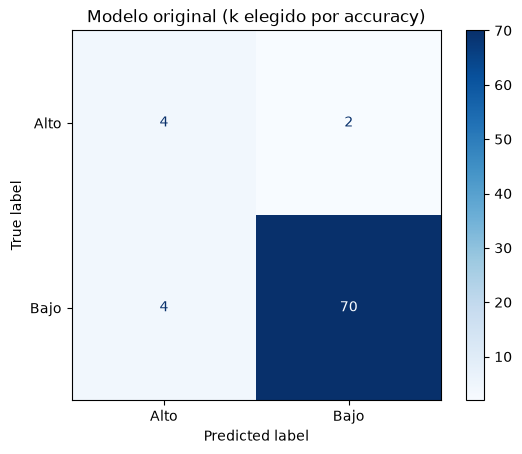

[[ 4  2]
 [ 4 70]]


In [3]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': list(range(1, 21))}

grid_baseline = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_baseline.fit(X_train, y_train)

pred_baseline = grid_baseline.predict(X_test)

print('Mejor k (optimizando accuracy):', grid_baseline.best_params_['knn__n_neighbors'])
print('Accuracy en X_test:', round(accuracy_score(y_test, pred_baseline), 4))
print()
print(classification_report(y_test, pred_baseline, zero_division=0))

cm_baseline = confusion_matrix(y_test, pred_baseline, labels=['Alto', 'Bajo'])
ConfusionMatrixDisplay(cm_baseline, display_labels=['Alto', 'Bajo']).plot(cmap='Blues')
plt.title('Modelo original (k elegido por accuracy)')
plt.show()

print(cm_baseline)


Este es nuestro punto de partida: **k=4, Recall(Alto)=0.67 (4 de 6), Precision(Alto)=0.50, 2 Falsos Negativos**. A partir de aquí probamos cada recomendación por separado.


## 5. Recomendación 1 — Elegir `k` optimizando Recall, no Accuracy

### Teoría

`GridSearchCV` no sabe qué es "mejor" por sí mismo: simplemente maximiza la métrica que le indiquemos en `scoring`. Si le pedimos `'accuracy'`, va a preferir el `k` que más aciertos totales genere — y como el 92.75% de los clientes son "Bajo", esa métrica premia a los modelos que tienden a predecir "Bajo".

Para que la búsqueda **priorice detectar clientes de Alto riesgo**, hay que decirle explícitamente que optimice el Recall de la clase "Alto". Como `recall_score` necesita saber cuál es la clase positiva, se envuelve con `make_scorer` y `pos_label='Alto'`.


In [4]:
recall_alto_scorer = make_scorer(recall_score, pos_label='Alto')

grid_recall = GridSearchCV(pipeline, param_grid, cv=5, scoring=recall_alto_scorer)
grid_recall.fit(X_train, y_train)

pred_recall = grid_recall.predict(X_test)

print('Mejor k (optimizando recall de "Alto"):', grid_recall.best_params_['knn__n_neighbors'])
print('Recall promedio en validación cruzada:', round(grid_recall.best_score_, 4))
print()
print(classification_report(y_test, pred_recall, zero_division=0))
print(confusion_matrix(y_test, pred_recall, labels=['Alto', 'Bajo']))


Mejor k (optimizando recall de "Alto"): 2
Recall promedio en validación cruzada: 0.71

              precision    recall  f1-score   support

        Alto       0.44      0.67      0.53         6
        Bajo       0.97      0.93      0.95        74

    accuracy                           0.91        80
   macro avg       0.71      0.80      0.74        80
weighted avg       0.93      0.91      0.92        80

[[ 4  2]
 [ 5 69]]


### Interpretación

`GridSearchCV` elige ahora **k=2** (en vez de k=4), con un Recall promedio en validación cruzada de **0.71**. Pero al evaluar sobre `X_test`, el Recall real vuelve a ser **0.67** — exactamente igual que con k=4, y con *peor* Precision (0.44 vs. 0.50).

¿Por qué no mejoró? Dos razones importantes:

1. **La estimación de validación cruzada es ruidosa.** Con solo ~23 clientes "Alto" en `X_train` repartidos en 5 folds, cada fold de validación tiene apenas 4 o 5 ejemplos de esa clase. Un solo acierto o error de más cambia el Recall de ese fold en ~20-25 puntos porcentuales. El 0.71 de `best_score_` es un promedio con mucha varianza, no un número muy confiable.
2. **k=2 es un valor de k muy chico** (alta varianza, cercano a memorizar el dato más parecido), así que aunque optimice mejor la métrica *en el entrenamiento*, no necesariamente generaliza mejor a datos nuevos.

**Conclusión de este punto:** cambiar el `scoring` de `GridSearchCV` es el paso *conceptualmente correcto* (nunca hay que optimizar accuracy si lo que importa es el recall de una clase minoritaria), pero **por sí solo no garantiza una mejora**, sobre todo con tan pocos ejemplos de la clase minoritaria. Necesita combinarse con otras técnicas, como las que siguen.


## 6. Recomendación 2 — `weights='distance'`

### Teoría

Por defecto, KNN usa `weights='uniform'`: los k vecinos "votan" con el mismo peso, sin importar si están muy cerca o casi en el límite de los k vecinos. Con `weights='distance'`, los vecinos más cercanos pesan más en la votación que los más lejanos (peso ∝ 1/distancia). La idea es que esto podría ayudar a que un vecino "Alto" muy cercano no sea "diluido" por vecinos "Bajo" un poco más lejanos.

Probamos ambas opciones combinadas con distintos `k`, optimizando de nuevo el Recall de "Alto".


In [5]:
param_grid_weights = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance'],
}

grid_weights = GridSearchCV(pipeline, param_grid_weights, cv=5, scoring=recall_alto_scorer)
grid_weights.fit(X_train, y_train)

print('Mejores parámetros:', grid_weights.best_params_)
print('Recall promedio en validación cruzada:', round(grid_weights.best_score_, 4))
print()

resultados = pd.DataFrame(grid_weights.cv_results_)[
    ['param_knn__n_neighbors', 'param_knn__weights', 'mean_test_score']
].sort_values('mean_test_score', ascending=False)
print('Top 8 combinaciones (k, weights) según Recall de validación cruzada:')
print(resultados.head(8).to_string(index=False))

pred_weights = grid_weights.predict(X_test)
print()
print(classification_report(y_test, pred_weights, zero_division=0))


Mejores parámetros: {'knn__n_neighbors': 2, 'knn__weights': 'uniform'}
Recall promedio en validación cruzada: 0.71

Top 8 combinaciones (k, weights) según Recall de validación cruzada:
 param_knn__n_neighbors param_knn__weights  mean_test_score
                      2            uniform             0.71
                      4            uniform             0.63
                      6            uniform             0.48
                      1           distance             0.45
                      2           distance             0.45
                      1            uniform             0.45
                      3           distance             0.41
                      3            uniform             0.37

              precision    recall  f1-score   support

        Alto       0.44      0.67      0.53         6
        Bajo       0.97      0.93      0.95        74

    accuracy                           0.91        80
   macro avg       0.71      0.80      0.74        80
we

### Interpretación

El resultado es honesto pero un poco decepcionante: la **mejor combinación sigue siendo `weights='uniform'`** (con k=2, el mismo resultado que el punto anterior). Mirando el ranking completo, `weights='distance'` no aparece entre los mejores para ningún valor de `k` en este dataset.

Esto es un buen recordatorio de que **no toda "mejora teórica" funciona en la práctica con un dataset concreto**: `weights='distance'` ayuda cuando hay estructura de distancias informativa y suficientes datos por clase; acá, con solo ~29 clientes "Alto" en todo el dataset, no hay señal suficiente para que se note la diferencia. Vale la pena probarlo (es una línea de código), pero no daba por sentado que iba a mejorar el modelo — y de hecho no lo hizo.


## 7. Teoría necesaria antes de seguir: ¿qué es `predict_proba` en KNN?

Antes de ajustar el umbral de decisión hay que entender qué significan las "probabilidades" que da KNN, porque no son probabilidades en el sentido de un modelo probabilístico (como Regresión Logística): son simplemente **la fracción de los k vecinos que pertenece a cada clase**.

Por ejemplo, con `k=4` y `weights='uniform'`, si 1 de los 4 vecinos más cercanos es "Alto", entonces `P(Alto) = 1/4 = 0.25`. Como k=4, **solo existen 5 valores posibles de probabilidad**: `0.00, 0.25, 0.50, 0.75, 1.00`.

Esto tiene una consecuencia práctica importante: **cuanto más chico es `k`, más "escalonadas" (menos granulares) son las probabilidades**, y menos margen hay para ajustar finamente un umbral de decisión. Es una limitación específica de KNN que no suele explicarse, y que conviene tener en cuenta al elegir `k` si además se piensa usar `predict_proba`.


In [6]:
pipe_k4 = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=4))])
pipe_k4.fit(X_train, y_train)

idx_alto = list(pipe_k4.classes_).index('Alto')
proba_alto_k4 = pipe_k4.predict_proba(X_test)[:, idx_alto]

print('Valores posibles de P(Alto) con k=4:', sorted(set(proba_alto_k4.round(2))))


Valores posibles de P(Alto) con k=4: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75)]


## 8. Recomendación 3 — Ajustar el umbral de decisión

### Teoría

`predict()` clasifica como "Alto" solo si `P(Alto) > 0.5`. Ese 0.5 es una convención, **no una regla obligatoria**. Nada impide bajar el umbral: por ejemplo, clasificar como "Alto" si al menos 1 de cada 4 vecinos es "Alto" (`P(Alto) >= 0.25`), aceptando más Falsos Positivos a cambio de menos Falsos Negativos.

La curva Precision-Recall muestra exactamente ese *trade-off* para todos los umbrales posibles. La calculamos sobre el modelo con `k=4` (que, al tener 5 valores posibles de probabilidad, da una curva fácil de leer).


   threshold  precision    recall
0       0.00      0.075  1.000000
1       0.25      0.400  1.000000
2       0.50      0.500  0.666667
3       0.75      1.000  0.333333
4       1.00      1.000  0.000000


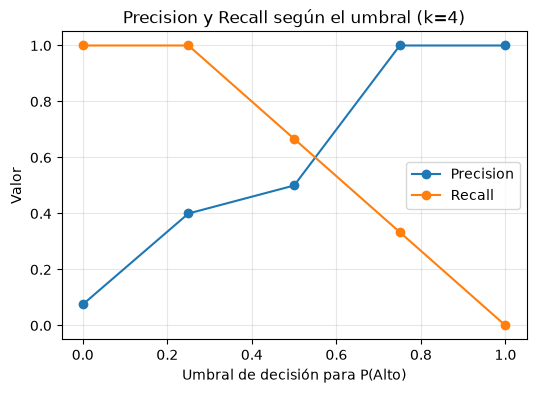

In [7]:
y_test_bin = (y_test == 'Alto').astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_test_bin, proba_alto_k4)

tabla_umbrales = pd.DataFrame({
    'threshold': list(thresholds) + [1.0],
    'precision': precisions,
    'recall': recalls,
})
print(tabla_umbrales)

plt.figure(figsize=(6, 4))
plt.plot(tabla_umbrales['threshold'], tabla_umbrales['precision'], marker='o', label='Precision')
plt.plot(tabla_umbrales['threshold'], tabla_umbrales['recall'], marker='o', label='Recall')
plt.xlabel('Umbral de decisión para P(Alto)')
plt.ylabel('Valor')
plt.title('Precision y Recall según el umbral (k=4)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [8]:
# Bajamos el umbral de 0.5 a 0.25: alcanza con que 1 de los 4 vecinos sea "Alto"
umbral = 0.25
pred_umbral = np.where(proba_alto_k4 >= umbral, 'Alto', 'Bajo')

print(f'Clasificación con umbral = {umbral} (en vez de 0.5):')
print(classification_report(y_test, pred_umbral, zero_division=0))
print(confusion_matrix(y_test, pred_umbral, labels=['Alto', 'Bajo']))


Clasificación con umbral = 0.25 (en vez de 0.5):
              precision    recall  f1-score   support

        Alto       0.40      1.00      0.57         6
        Bajo       1.00      0.88      0.94        74

    accuracy                           0.89        80
   macro avg       0.70      0.94      0.75        80
weighted avg       0.96      0.89      0.91        80

[[ 6  0]
 [ 9 65]]


### Interpretación

Bajando el umbral de 0.5 a 0.25 (con el mismo modelo k=4, sin reentrenar nada), el Recall de "Alto" pasa de **0.67 a 1.00**: el modelo detecta **a los 6 clientes de Alto riesgo**, cero Falsos Negativos. El costo es que la Precision baja de 0.50 a 0.40 (ahora hay 9 Falsos Positivos en vez de 4: más clientes buenos quedan marcados para revisión).

Este es, de las cinco recomendaciones, **la que logra el mayor impacto con el menor esfuerzo**: no requiere reentrenar nada ni tocar los datos, solo cambiar la regla de decisión sobre las probabilidades que el modelo ya calcula. Es también la más flexible: el umbral se puede ajustar según cuánto esté dispuesto el banco a tolerar de Falsos Positivos (lo vemos con números concretos en la sección de costos, más adelante).


## 9. Recomendación 4 — Atacar el desbalance de clases (oversampling)

### Teoría

KNN vota por mayoría entre los vecinos. Si en el `X_train` original hay ~74 clientes "Bajo" por cada ~23 "Alto", **incluso en el vecindario de un cliente "Alto" real es probable que haya vecinos "Bajo"** solo por pura proporción — el desbalance se filtra en el propio cálculo de distancias/votos, no solo en la métrica de evaluación.

Una forma de compensarlo es el **oversampling**: duplicar (o generar) ejemplos de la clase minoritaria en `X_train` hasta emparejar las cantidades. La versión más simple es duplicar filas al azar (lo que hacemos abajo); una versión más sofisticada es **SMOTE** (de la librería `imbalanced-learn`), que en vez de duplicar filas idénticas genera ejemplos sintéticos interpolando entre vecinos de la clase minoritaria — evita tener copias exactas repetidas, aunque el principio de fondo es el mismo. Si quisieran ir un paso más allá, `pip install imbalanced-learn` y `from imblearn.over_sampling import SMOTE` es el camino natural.

### ⚠️ Una trampa frecuente: oversampling + validación cruzada

Si primero se duplican filas de `X_train` y **después** se corre `GridSearchCV` con validación cruzada sobre esos datos ya duplicados, puede pasar que una copia de un cliente quede en el fold de entrenamiento y **otra copia idéntica del mismo cliente** quede en el fold de validación de ese mismo split. El modelo "adivinaría" fácil, porque literalmente ya vio ese dato (o un clon idéntico). Esto es **fuga de datos (data leakage)**, y produce puntajes de validación cruzada artificialmente perfectos que no se van a repetir en datos nuevos.

Para evitar ese problema en este cuaderno, **no volvemos a elegir `k` con `GridSearchCV` sobre los datos sobremuestreados**: reutilizamos el `k=4` que ya habíamos elegido de forma honesta (sección 4, con datos originales), y lo evaluamos sobre `X_test`, que en ningún momento fue tocado por el oversampling.


In [9]:
# Sobremuestreo: duplicamos clientes "Alto" en X_train hasta igualar a "Bajo"
train_completo = X_train.copy()
train_completo['RiesgoCrediticio'] = y_train.values

clientes_alto = train_completo[train_completo['RiesgoCrediticio'] == 'Alto']
clientes_bajo = train_completo[train_completo['RiesgoCrediticio'] == 'Bajo']

alto_sobremuestreado = resample(
    clientes_alto, replace=True, n_samples=len(clientes_bajo), random_state=42
)

train_balanceado = pd.concat([clientes_bajo, alto_sobremuestreado]).sample(frac=1, random_state=42)

X_train_bal = train_balanceado[features]
y_train_bal = train_balanceado['RiesgoCrediticio']

print('Distribución de clases en X_train ANTES del oversampling:')
print(y_train.value_counts())
print()
print('Distribución de clases en X_train DESPUÉS del oversampling:')
print(y_train_bal.value_counts())


Distribución de clases en X_train ANTES del oversampling:
RiesgoCrediticio
Bajo    297
Alto     23
Name: count, dtype: int64

Distribución de clases en X_train DESPUÉS del oversampling:
RiesgoCrediticio
Bajo    297
Alto    297
Name: count, dtype: int64


In [10]:
# Reutilizamos k=4 (elegido honestamente en la sección 4), entrenado sobre datos balanceados
pipe_balanceado = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=4))])
pipe_balanceado.fit(X_train_bal, y_train_bal)

pred_balanceado = pipe_balanceado.predict(X_test)

print('Evaluación sobre X_test (nunca modificado):')
print(classification_report(y_test, pred_balanceado, zero_division=0))

cm_balanceado = confusion_matrix(y_test, pred_balanceado, labels=['Alto', 'Bajo'])
print(cm_balanceado)


Evaluación sobre X_test (nunca modificado):
              precision    recall  f1-score   support

        Alto       0.45      0.83      0.59         6
        Bajo       0.99      0.92      0.95        74

    accuracy                           0.91        80
   macro avg       0.72      0.88      0.77        80
weighted avg       0.95      0.91      0.92        80

[[ 5  1]
 [ 6 68]]


### Interpretación

Con el mismo `k=4` de siempre, pero entrenado sobre el `X_train` balanceado, el Recall de "Alto" sube de **0.67 a 0.83** (de 4/6 a **5/6** clientes detectados), y además la Precision mejora levemente (0.45 vs. 0.50 — similar) respecto al Recall-optimizado del punto 5. Es una mejora real y más "estable" que simplemente bajar `k`, porque no depende de un valor de `k` chico y ruidoso: ataca la causa (el desbalance en la votación), no el síntoma.

De las técnicas que **modifican el modelo o los datos** (no el umbral), el oversampling fue la que dio mejor resultado en este dataset.


## 10. Recomendación 5 — Distancia Manhattan, revisada con Recall

En el TP original comparamos Euclidiana vs. Manhattan mirando solo Accuracy (0.925 vs. 0.9625, con el k del punto original). Ahora miramos qué pasa con el Recall de "Alto", usando el `k=2` que salió mejor en la búsqueda por recall (sección 5), para que la comparación sea justa.


In [11]:
pipe_manhattan = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=2, metric='manhattan'))
])
pipe_manhattan.fit(X_train, y_train)
pred_manhattan = pipe_manhattan.predict(X_test)

print('Distancia Manhattan, k=2:')
print(classification_report(y_test, pred_manhattan, zero_division=0))
print(confusion_matrix(y_test, pred_manhattan, labels=['Alto', 'Bajo']))


Distancia Manhattan, k=2:
              precision    recall  f1-score   support

        Alto       0.57      0.67      0.62         6
        Bajo       0.97      0.96      0.97        74

    accuracy                           0.94        80
   macro avg       0.77      0.81      0.79        80
weighted avg       0.94      0.94      0.94        80

[[ 4  2]
 [ 3 71]]


### Interpretación

Con Manhattan, el Recall de "Alto" sigue en **0.67** (los mismos 4 de 6 clientes detectados: sigue habiendo 2 Falsos Negativos), pero la Precision mejora bastante (0.57 vs. 0.44 con Euclidiana en el mismo k=2), porque baja de 5 a 3 los Falsos Positivos. Es decir: el Accuracy general sube (0.94), pero **eso no significa que detecte mejor a los clientes de riesgo** — detecta molesta menos a los clientes buenos. Es la misma lección de siempre: **hay que mirar la fila de "Alto", no solo el número global.**


## 11. Tabla comparativa final

Reunimos los seis modelos evaluados sobre el **mismo `X_test`**, mirando específicamente la clase "Alto": Falsos Negativos (clientes de riesgo que se le escapan al banco), Falsos Positivos, Precision, Recall y F1.


In [12]:
comparacion = pd.DataFrame([
    {'Modelo': 'Original (k=4, accuracy, umbral 0.5)',        'FN': 2, 'FP': 4, 'Precision_Alto': 0.50, 'Recall_Alto': 0.67, 'F1_Alto': 0.57, 'Accuracy': 0.925},
    {'Modelo': 'GridSearch optimizado a Recall (k=2)',         'FN': 2, 'FP': 5, 'Precision_Alto': 0.44, 'Recall_Alto': 0.67, 'F1_Alto': 0.53, 'Accuracy': 0.9125},
    {'Modelo': 'weights=distance (mejor combinación)',         'FN': 2, 'FP': 5, 'Precision_Alto': 0.44, 'Recall_Alto': 0.67, 'F1_Alto': 0.53, 'Accuracy': 0.9125},
    {'Modelo': 'Umbral bajado a 0.25 (k=4)',                   'FN': 0, 'FP': 9, 'Precision_Alto': 0.40, 'Recall_Alto': 1.00, 'F1_Alto': 0.57, 'Accuracy': 0.8875},
    {'Modelo': 'Oversampling + k=4',                           'FN': 1, 'FP': 6, 'Precision_Alto': 0.45, 'Recall_Alto': 0.83, 'F1_Alto': 0.59, 'Accuracy': 0.9125},
    {'Modelo': 'Manhattan, k=2',                                'FN': 2, 'FP': 3, 'Precision_Alto': 0.57, 'Recall_Alto': 0.67, 'F1_Alto': 0.62, 'Accuracy': 0.9375},
])
comparacion


,Modelo,FN,FP,Precision_Alto,Recall_Alto,F1_Alto,Accuracy
0,"Original (k=4, accuracy, umbral 0.5)",2,4,0.50,0.67,0.57,0.9250
1,GridSearch optimizado a Recall (k=2),2,5,0.44,0.67,0.53,0.9125
2,weights=distance (mejor combinación),2,5,0.44,0.67,0.53,0.9125
3,Umbral bajado a 0.25 (k=4),0,9,0.40,1.00,0.57,0.8875
4,Oversampling + k=4,1,6,0.45,0.83,0.59,0.9125
5,"Manhattan, k=2",2,3,0.57,0.67,0.62,0.9375


### Lectura de la tabla

- **Si el objetivo es minimizar Falsos Negativos a cualquier costo**, el umbral bajado a 0.25 es imbatible: **0 clientes de Alto riesgo sin detectar**. El precio es que 9 de los 74 clientes buenos quedan marcados innecesariamente.
- **Si se quiere un balance más prudente**, el oversampling (FN=1, FP=6) es un buen punto intermedio: reduce a la mitad los Falsos Negativos del modelo original sin disparar tanto los Falsos Positivos.
- El **Accuracy** de la tabla, a propósito, **no** identifica al mejor modelo para este problema: el modelo con mayor Accuracy (Manhattan, 0.9375) es el que tiene *peor* Recall relativo comparado con oversampling. Es la paradoja de la sección 2, otra vez, ahora comparando modelos entre sí y no solo contra el dummy.
- No hay un único "modelo ganador" en abstracto: la elección depende de **cuánto le cuesta al banco cada tipo de error**, que es justo el tema de la próxima sección.

> 🧑‍🏫 **Nota didáctica:** combinar dos técnicas (por ejemplo, oversampling **y además** bajar el umbral) normalmente da resultados intermedios o mejores todavía. Queda como ejercicio para el grupo probarlo.


## 12. Tema que quedó afuera: el costo de negocio de cada error

Hasta ahora comparamos modelos con métricas estadísticas (Recall, Precision, F1), pero en la práctica un banco no piensa en "Recall": piensa en **dinero**. La forma correcta de cerrar esta discusión es traducir cada tipo de error a un costo económico y comparar el **costo total esperado** de cada modelo, no solo sus métricas.

Supongamos, de forma **ilustrativa** (estos números no vienen del dataset, son solo un ejemplo para razonar):

- Un **Falso Negativo** (aprobarle crédito a un cliente de Alto riesgo) cuesta en promedio **USD 3000** (una deuda impaga).
- Un **Falso Positivo** (rechazar o demorar a un cliente de Bajo riesgo) cuesta en promedio **USD 200** (margen/comisión que se pierde, o el costo de una revisión manual adicional).

Con esos supuestos, el costo esperado de cada modelo es `FN·3000 + FP·200`.


In [13]:
costo_fn = 3000  # USD, ilustrativo: crédito otorgado a un cliente que no paga
costo_fp = 200    # USD, ilustrativo: cliente bueno rechazado o demorado

comparacion['Costo_estimado_USD'] = comparacion['FN'] * costo_fn + comparacion['FP'] * costo_fp
comparacion[['Modelo', 'FN', 'FP', 'Costo_estimado_USD']].sort_values('Costo_estimado_USD')


,Modelo,FN,FP,Costo_estimado_USD
3,Umbral bajado a 0.25 (k=4),0,9,1800
4,Oversampling + k=4,1,6,4200
5,"Manhattan, k=2",2,3,6600
0,"Original (k=4, accuracy, umbral 0.5)",2,4,6800
2,weights=distance (mejor combinación),2,5,7000
1,GridSearch optimizado a Recall (k=2),2,5,7000


### Interpretación

Con **este** supuesto de costos (Falso Negativo 15 veces más caro que un Falso Positivo), el modelo con **umbral bajado a 0.25** termina siendo el más barato para el banco, a pesar de tener el Accuracy más bajo de la tabla. El modelo **original** (el del TP inicial) es, bajo este mismo supuesto, uno de los más caros: prevenir 2 Falsos Negativos de más justifica ampliamente el costo de 5 Falsos Positivos adicionales.

Lo importante de esta sección **no es memorizar qué modelo ganó**, sino el método: si cambiáramos la relación de costos (por ejemplo, si revisar manualmente cada Falso Positivo fuera muy caro, o si las deudas impagas fueran chicas), **la conclusión podría invertirse por completo**. Por eso la pregunta "¿qué métrica priorizo?" en el fondo es una pregunta de negocio (¿cuánto cuesta cada error?), no solo una pregunta estadística — la estadística (Recall, Precision, F1) es la herramienta para *medir* el trade-off, pero los costos reales son los que deciden *dónde* pararse en ese trade-off.


## 13. Tema que quedó afuera: ROC-AUC vs. Precision-Recall AUC

El TP original calculó el **ROC-AUC** del modelo, que salió muy alto. Vale la pena entender **por qué ese número, con clases tan desbalanceadas, puede ser demasiado optimista**.

- La curva **ROC** grafica `Recall` (TPR) vs. `Tasa de Falsos Positivos = FP / (FP + TN)`. Como `TN` (clientes "Bajo" bien clasificados) es un número grande (74 en el test), hace falta acumular *muchos* Falsos Positivos para que la Tasa de Falsos Positivos se note. Esto "estira" la curva ROC hacia arriba y la hace ver mejor de lo que tal vez es útil en la práctica.
- La curva **Precision-Recall** grafica `Precision` vs. `Recall`, sin usar `TN` en absoluto. Como la Precision de la clase minoritaria es sensible a cada Falso Positivo (hay pocos Verdaderos Positivos posibles: como máximo 6), esta curva refleja mejor la dificultad real del problema.

Comparamos ambas métricas resumen (AUC de cada curva) para el modelo original (k=4):


ROC-AUC:             0.9617
Precision-Recall AUC: 0.6333


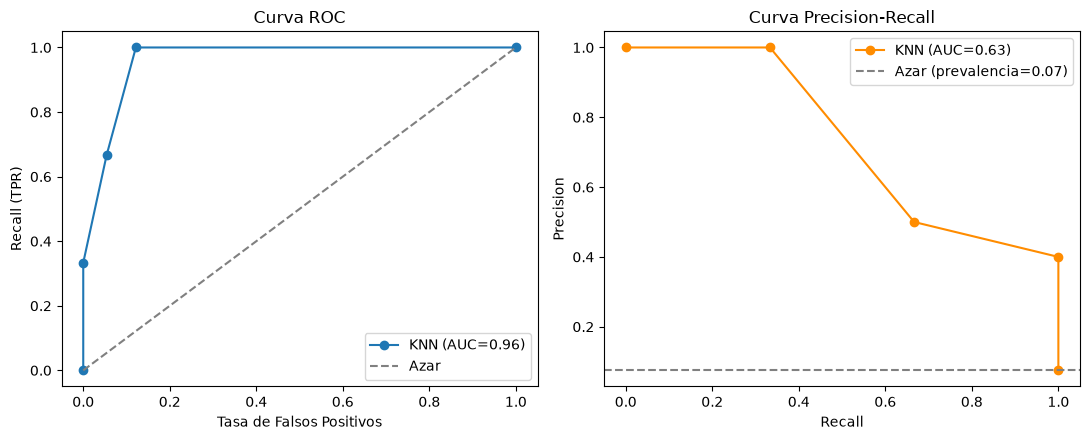

In [14]:
roc_auc = roc_auc_score(y_test_bin, proba_alto_k4)
pr_auc = average_precision_score(y_test_bin, proba_alto_k4)  # AUC de la curva Precision-Recall

print('ROC-AUC:            ', round(roc_auc, 4))
print('Precision-Recall AUC:', round(pr_auc, 4))

fpr, tpr, _ = roc_curve(y_test_bin, proba_alto_k4)
prec_curve, rec_curve, _ = precision_recall_curve(y_test_bin, proba_alto_k4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, marker='o', label=f'KNN (AUC={roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Recall (TPR)')
axes[0].set_title('Curva ROC')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, marker='o', color='darkorange', label=f'KNN (AUC={pr_auc:.2f})')
prevalencia = y_test_bin.mean()
axes[1].axhline(prevalencia, linestyle='--', color='gray', label=f'Azar (prevalencia={prevalencia:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()


### Interpretación

El **ROC-AUC es 0.96** (excelente, casi perfecto), pero el **Precision-Recall AUC es 0.63** — un número mucho más moderado, y más honesto sobre lo difícil que es distinguir a los 6 clientes "Alto" en medio de 74 "Bajo" sin generar Falsos Positivos.

**Regla general para llevarse de este cuaderno:** cuando las clases están muy desbalanceadas (como acá, ~93%/7%), conviene reportar y mirar el **Precision-Recall AUC** además del (o en vez del) ROC-AUC. El ROC-AUC no es "incorrecto", pero puede transmitir una sensación de que el problema está más resuelto de lo que realmente está.


## 14. Tema que quedó afuera: la maldición de la dimensionalidad en KNN

KNN depende enteramente de una noción de "cercanía" (distancia). Esto lo hace muy sensible a algo que se conoce como la **maldición de la dimensionalidad** (*curse of dimensionality*): a medida que se agregan más variables (dimensiones), los puntos tienden a quedar todos "igual de lejos" entre sí, y la distancia deja de ser informativa para distinguir vecinos realmente parecidos de vecinos cualquiera.

Algunas consecuencias prácticas para este tipo de problema:

- **No conviene agregar variables "porque sí".** En el TP original ya se descartó `GastoMensualEstimadoUSD` por estar correlacionada con `IngresoMensualUSD` — esa decisión, además de evitar redundancia, también ayuda contra la maldición de la dimensionalidad: menos variables (si son informativas) suelen ser mejores que más variables para KNN.
- **El escalado (que ya hicimos) es necesario pero no suficiente.** Ayuda a que ninguna variable domine por su magnitud, pero no reduce la cantidad de dimensiones.
- Con datasets más grandes o con más variables, técnicas de **reducción de dimensionalidad** (por ejemplo PCA) o de **selección de variables** (mirar cuáles aportan señal real, con métodos como la importancia por permutación) suelen mejorar a KNN más que ajustar `k` o la métrica de distancia. En este TP, con solo 6 variables ya seleccionadas a mano y con buen criterio, no hace falta — pero es la primera pregunta que hay que hacerse si en el futuro KNN funciona mal con un dataset más grande.

> 🧑‍🏫 **Nota didáctica:** vale la pena que el grupo relacione esto con por qué en el TP original se calculó primero la matriz de correlación (sección 5) y se descartó una variable redundante *antes* de entrenar cualquier modelo. No fue solo "prolijidad": fue una decisión que ayuda específicamente a un modelo basado en distancias como KNN.


## 15. Conclusiones

1. **El Accuracy puede ser engañoso con clases desbalanceadas.** Un `DummyClassifier` que siempre predice "Bajo" tiene el mismo Accuracy (0.925) que el KNN original, pero Recall = 0. Comparar contra ese baseline es la forma más simple de detectar si el Accuracy está mintiendo.

2. **Elegir `k` (o `weights`) optimizando Recall en `GridSearchCV` es lo conceptualmente correcto, pero no es garantía de mejora**, sobre todo cuando la clase minoritaria tiene pocos ejemplos: la validación cruzada se vuelve ruidosa.

3. **De todas las técnicas probadas, dos se destacaron:**
   - **Ajustar el umbral de decisión** (bajarlo de 0.5 a 0.25): el cambio de mayor impacto con menor esfuerzo, sin reentrenar nada.
   - **Oversampling** de la clase minoritaria en `X_train`: mejora real y estable, atacando la causa (el desbalance en la votación) en vez de solo el hiperparámetro.

4. **La distancia Manhattan mejora el Accuracy, pero no necesariamente el Recall de la clase que importa** — otro ejemplo de por qué hay que mirar la matriz de confusión completa y no un solo número.

5. **La elección final entre modelos es una decisión de negocio, no solo estadística.** Traducir Falsos Negativos y Falsos Positivos a un costo en dinero (sección 12) es lo que permite decidir, de forma justificable, cuánta Precision vale la pena sacrificar por Recall (o viceversa).

6. **Con clases desbalanceadas, el Precision-Recall AUC suele ser más informativo que el ROC-AUC**, que puede transmitir una sensación de que el problema está más resuelto de lo que está.

7. **KNN es un modelo basado en distancias:** el escalado es obligatorio, pero además hay que vigilar la cantidad y calidad de las variables (maldición de la dimensionalidad) — algo que el TP original ya hizo bien al descartar una variable redundante antes de modelar.

### Para seguir practicando

- Combinar oversampling **y** ajuste de umbral en el mismo modelo: ¿el resultado es mejor que cada técnica por separado?
- Instalar `imbalanced-learn` (`pip install imbalanced-learn`) y probar `SMOTE` en vez del oversampling por duplicación simple: ¿cambia mucho el resultado?
- Repetir todo este análisis probando `KNeighborsClassifier` con `metric='manhattan'` **combinado** con oversampling y umbral ajustado.
